# 30. 가격 데이터 탐색 및 분석

## 목적
Price Anomaly Detection 모델 구축을 위한 가격 데이터 탐색 및 이해.

## 분석 항목
1. **가격 분포 분석**: 전체 가격 분포, 카테고리별 분포
2. **가격 통계량 계산**: 평균, 중앙값, 표준편차, IQR
3. **이상치 현황 파악**: 기존 이상치 비율 분석
4. **카테고리별 가격 패턴**: 카테고리간 가격 차이
5. **시계열 패턴** (있는 경우): 가격 변동 추이

## 데이터 소스
- SelF DB: `products_product` 테이블
- 가격 필드: `price`, `original_price`, `discount_rate`

In [1]:
# 필수 라이브러리 임포트
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계
from scipy import stats

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 1. 데이터 로드

In [2]:
# Django 설정을 통한 DB 연결 시도
# - 이 셀은 단독 실행해도 동작하도록 필요한 import를 포함합니다.
# - Jupyter 환경은 내부적으로 async 컨텍스트를 사용할 수 있어 Django ORM이 막히는 경우가 있습니다.
#   노트북 분석 용도에 한해 안전장치를 우회합니다.

import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

try:
    # 실행 위치(CWD)에 관계없이 backend 경로를 안정적으로 찾기
    current_dir = Path.cwd().resolve()
    repo_root = None
    for candidate in [current_dir, *current_dir.parents]:
        if (candidate / 'backend').exists():
            repo_root = candidate
            break

    if repo_root is None:
        raise FileNotFoundError('backend 디렉토리를 찾을 수 없습니다.')

    backend_dir = repo_root / 'backend'
    sys.path.insert(0, str(backend_dir))

    os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'project_self.settings')

    # 노트북(호스트)에서 Docker Postgres로 접근하기 위한 기본값
    # - docker-compose.yml 기준 포트는 5432로 호스트에 바인딩되어 있습니다.
    # - 이미 환경변수가 설정되어 있으면(setdefault) 덮어쓰지 않습니다.
    os.environ.setdefault('DB_ENGINE', 'django.db.backends.postgresql')
    os.environ.setdefault('DB_NAME', 'selfdb')
    os.environ.setdefault('DB_USER', 'selfuser')
    os.environ.setdefault('DB_PASSWORD', 'selfpass')
    os.environ.setdefault('DB_HOST', 'localhost')
    os.environ.setdefault('DB_PORT', '5432')

    # Jupyter 환경에서 ORM 사용을 막는 안전장치 해제(분석 노트북 전용)
    os.environ.setdefault('DJANGO_ALLOW_ASYNC_UNSAFE', 'true')

    import django

    django.setup()

    from products.models import Product

    # 제품 데이터 로드 (모델 스키마에 존재하는 필드만 조회)
    # - 현재 Product 모델에는 discount_rate 필드가 없어서 FieldError가 발생할 수 있습니다.
    # - 할인율은 original_price와 price로 계산합니다.
    rows = list(
        Product.objects.select_related('category').values(
            'id',
            'name',
            'price',
            'original_price',
            'category_id',
            'category__name',
        )
    )

    def _calc_discount_rate(price, original_price):
        # 원가가 없거나 0이거나, 현재가가 원가보다 크면 할인 0으로 처리
        if original_price is None or original_price == 0:
            return 0.0
        if price is None:
            return 0.0
        if price >= original_price:
            return 0.0
        return round((1 - (price / original_price)) * 100, 2)

    df = pd.DataFrame(
        [
            {
                'product_id': r.get('id'),
                'name': r.get('name'),
                'price': float(r['price']) if r.get('price') is not None else None,
                'original_price': float(r['original_price']) if r.get('original_price') is not None else None,
                'discount_rate': _calc_discount_rate(r.get('price'), r.get('original_price')),
                'category_id': r.get('category_id'),
                'category_name': r.get('category__name') or '미분류',
            }
            for r in rows
        ]
    )

    print(f"DB에서 제품 데이터 로드: {len(df)}개")
    USE_REAL_DATA = True

except Exception as e:
    # DB가 "죽은" 게 아니라, 노트북 환경/설정/스키마/접속 문제로 로드에 실패한 경우가 대부분입니다.
    # 실패 원인을 출력하고, 분석을 계속하기 위해 시뮬레이션 데이터로 대체합니다.
    print(f"DB 로드 실패(시뮬레이션으로 대체): {e}")
    print("시뮬레이션 데이터 생성...")

    # 시뮬레이션 데이터 생성
    np.random.seed(42)
    n_products = 500
    n_categories = 10
    
    # 카테고리별 가격 분포 설정 (현실적인 가격 범위)
    category_price_params = {
        0: {'name': '신선식품', 'mean': 8000, 'std': 3000, 'min': 1000, 'max': 30000},
        1: {'name': '유제품', 'mean': 5000, 'std': 2000, 'min': 1000, 'max': 15000},
        2: {'name': '음료', 'mean': 3000, 'std': 1500, 'min': 500, 'max': 10000},
        3: {'name': '과자/스낵', 'mean': 4000, 'std': 2000, 'min': 500, 'max': 15000},
        4: {'name': '냉동식품', 'mean': 7000, 'std': 3000, 'min': 2000, 'max': 25000},
        5: {'name': '가공식품', 'mean': 6000, 'std': 2500, 'min': 1000, 'max': 20000},
        6: {'name': '건강식품', 'mean': 25000, 'std': 15000, 'min': 5000, 'max': 100000},
        7: {'name': '조미료/양념', 'mean': 5000, 'std': 3000, 'min': 1000, 'max': 20000},
        8: {'name': '생활용품', 'mean': 8000, 'std': 5000, 'min': 1000, 'max': 30000},
        9: {'name': '주류', 'mean': 15000, 'std': 10000, 'min': 3000, 'max': 50000}
    }
    
    products_data = []
    for i in range(n_products):
        cat_id = np.random.randint(0, n_categories)
        params = category_price_params[cat_id]
        
        # 정상 가격 생성
        price = np.random.normal(params['mean'], params['std'])
        price = np.clip(price, params['min'], params['max'])
        price = round(price / 100) * 100  # 100원 단위로 반올림
        
        # 5% 확률로 이상치 삽입
        if np.random.random() < 0.05:
            # 이상치: 매우 높거나 낮은 가격
            if np.random.random() < 0.5:
                price = price * np.random.uniform(3, 10)  # 비정상적으로 높음
            else:
                price = price * np.random.uniform(0.05, 0.2)  # 비정상적으로 낮음
            price = round(price / 100) * 100
        
        # 할인율 (0~50%)
        discount_rate = np.random.choice([0, 0, 0, 10, 20, 30, 40, 50], p=[0.4, 0.15, 0.15, 0.1, 0.08, 0.06, 0.04, 0.02])
        original_price = price / (1 - discount_rate/100) if discount_rate > 0 else price
        original_price = round(original_price / 100) * 100
        
        products_data.append({
            'product_id': i + 1,
            'name': f"{params['name']} 제품 {i+1}",
            'price': price,
            'original_price': original_price,
            'discount_rate': discount_rate,
            'category_id': cat_id,
            'category_name': params['name']
        })
    
    df = pd.DataFrame(products_data)
    print(f"시뮬레이션 데이터 생성: {len(df)}개")
    USE_REAL_DATA = False

print(f"\n데이터 shape: {df.shape}")
df.head()

DB에서 제품 데이터 로드: 1600개

데이터 shape: (1600, 7)


,product_id,name,price,original_price,discount_rate,category_id,category_name
0,1600,simplus 스위트 피클 슬라이스 680G,3490.0,NaN,0.0,13,라면/간편식품/통조림
1,1599,simplus 할라피뇨 슬라이스 340G,1990.0,NaN,0.0,13,라면/간편식품/통조림
2,1598,슬라이스드 오이피클 500G,2490.0,NaN,0.0,13,라면/간편식품/통조림
3,1597,직수입 블랙올리브 340G,2490.0,NaN,0.0,13,라면/간편식품/통조림
4,1596,직수입 블랙올리브 슬라이스 340G,2490.0,NaN,0.0,13,라면/간편식품/통조림


In [3]:
# 기본 통계 확인
print("=" * 50)
print("가격 데이터 기본 통계")
print("=" * 50)

# 결측치 확인
print("\n결측치:")
print(df[['price', 'original_price', 'discount_rate', 'category_id']].isnull().sum())

# 유효한 가격 데이터만 필터링
df_valid = df[df['price'].notna() & (df['price'] > 0)].copy()
print(f"\n유효한 가격 데이터: {len(df_valid)}개 ({len(df_valid)/len(df)*100:.1f}%)")

# 가격 통계
print("\n가격 통계:")
print(df_valid['price'].describe())

가격 데이터 기본 통계

결측치:
price                0
original_price    1229
discount_rate        0
category_id          0
dtype: int64

유효한 가격 데이터: 1600개 (100.0%)

가격 통계:
count     1600.000000
mean      7420.668750
std       6095.047251
min        890.000000
25%       3890.000000
50%       5990.000000
75%       9950.000000
max      64900.000000
Name: price, dtype: float64


## 2. 전체 가격 분포 분석

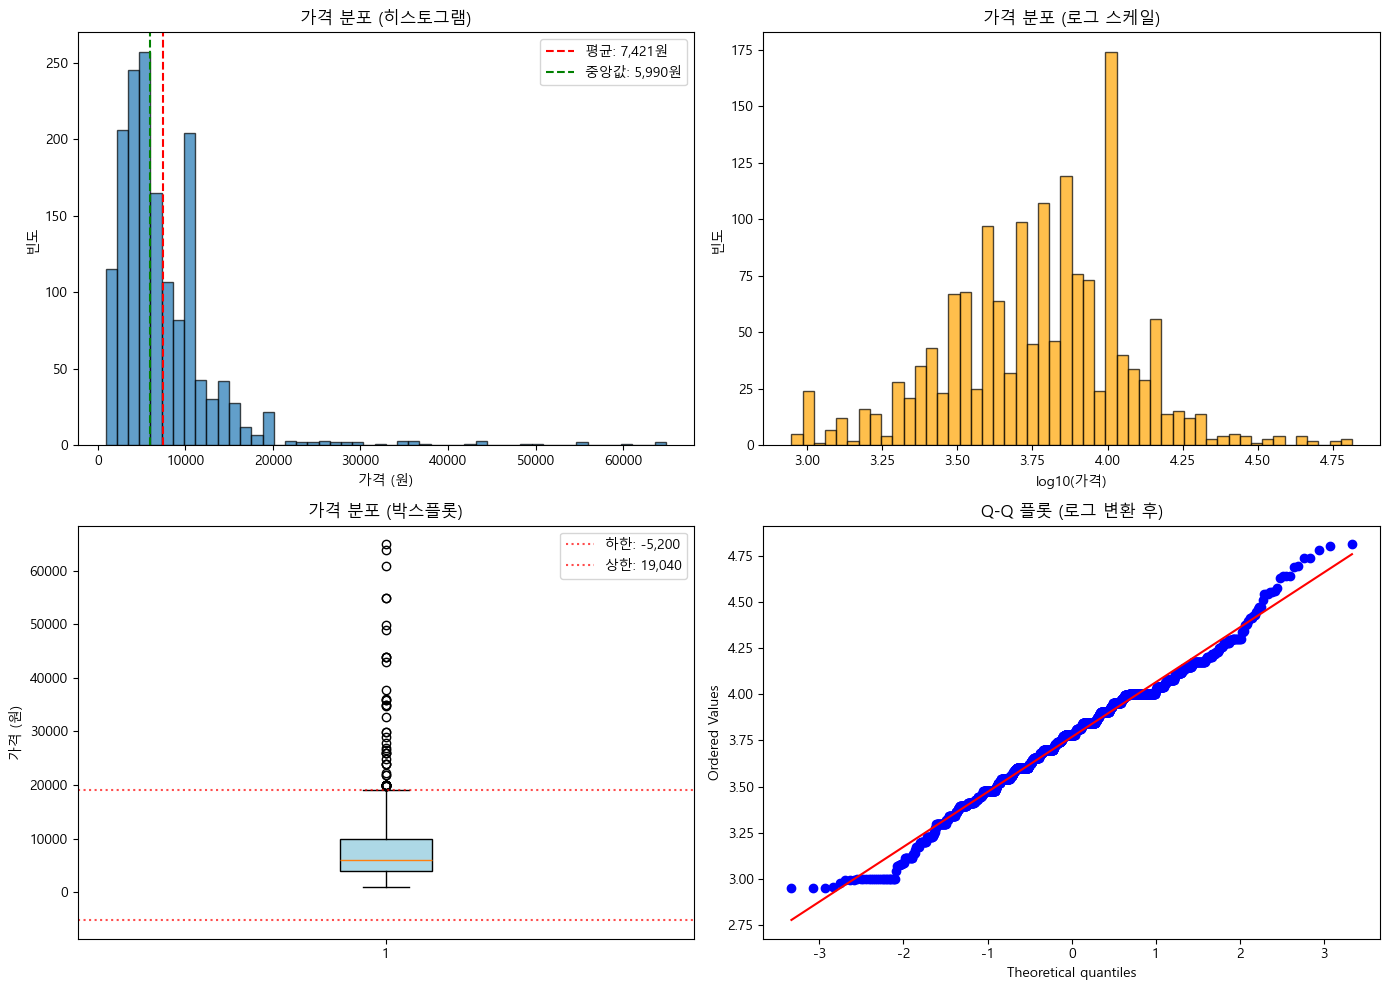

In [4]:
# 가격 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 히스토그램
ax1 = axes[0, 0]
ax1.hist(df_valid['price'], bins=50, edgecolor='black', alpha=0.7)
ax1.set_xlabel('가격 (원)')
ax1.set_ylabel('빈도')
ax1.set_title('가격 분포 (히스토그램)')
ax1.axvline(df_valid['price'].mean(), color='red', linestyle='--', label=f"평균: {df_valid['price'].mean():,.0f}원")
ax1.axvline(df_valid['price'].median(), color='green', linestyle='--', label=f"중앙값: {df_valid['price'].median():,.0f}원")
ax1.legend()

# 2. 로그 스케일 히스토그램
ax2 = axes[0, 1]
ax2.hist(np.log10(df_valid['price']), bins=50, edgecolor='black', alpha=0.7, color='orange')
ax2.set_xlabel('log10(가격)')
ax2.set_ylabel('빈도')
ax2.set_title('가격 분포 (로그 스케일)')

# 3. 박스플롯
ax3 = axes[1, 0]
bp = ax3.boxplot(df_valid['price'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax3.set_ylabel('가격 (원)')
ax3.set_title('가격 분포 (박스플롯)')

# IQR 기반 이상치 표시
Q1 = df_valid['price'].quantile(0.25)
Q3 = df_valid['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
ax3.axhline(lower_bound, color='red', linestyle=':', alpha=0.7, label=f'하한: {lower_bound:,.0f}')
ax3.axhline(upper_bound, color='red', linestyle=':', alpha=0.7, label=f'상한: {upper_bound:,.0f}')
ax3.legend(loc='upper right')

# 4. QQ 플롯 (정규성 확인)
ax4 = axes[1, 1]
stats.probplot(np.log10(df_valid['price']), dist="norm", plot=ax4)
ax4.set_title('Q-Q 플롯 (로그 변환 후)')

plt.tight_layout()
plt.show()

In [5]:
# 가격 통계량 계산
price_stats = {
    'count': len(df_valid),
    'mean': df_valid['price'].mean(),
    'median': df_valid['price'].median(),
    'std': df_valid['price'].std(),
    'min': df_valid['price'].min(),
    'max': df_valid['price'].max(),
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR,
    'lower_bound': lower_bound,
    'upper_bound': upper_bound,
    'skewness': df_valid['price'].skew(),
    'kurtosis': df_valid['price'].kurtosis()
}

print("=" * 50)
print("전체 가격 통계량")
print("=" * 50)
for key, value in price_stats.items():
    if isinstance(value, float):
        print(f"{key}: {value:,.2f}")
    else:
        print(f"{key}: {value}")

# IQR 기반 이상치 개수
n_outliers_iqr = ((df_valid['price'] < lower_bound) | (df_valid['price'] > upper_bound)).sum()
print(f"\nIQR 기반 이상치: {n_outliers_iqr}개 ({n_outliers_iqr/len(df_valid)*100:.2f}%)")

전체 가격 통계량
count: 1600
mean: 7,420.67
median: 5,990.00
std: 6,095.05
min: 890.00
max: 64,900.00
Q1: 3,890.00
Q3: 9,950.00
IQR: 6,060.00
lower_bound: -5,200.00
upper_bound: 19,040.00
skewness: 3.86
kurtosis: 24.60

IQR 기반 이상치: 49개 (3.06%)


## 3. 카테고리별 가격 분석

In [6]:
# 카테고리별 가격 통계
category_stats = df_valid.groupby('category_name').agg({
    'price': ['count', 'mean', 'median', 'std', 'min', 'max']
}).round(0)

category_stats.columns = ['count', 'mean', 'median', 'std', 'min', 'max']
category_stats = category_stats.sort_values('count', ascending=False)

print("=" * 70)
print("카테고리별 가격 통계")
print("=" * 70)
print(category_stats.to_string())

카테고리별 가격 통계
               count     mean  median      std     min      max
category_name                                                  
라면/간편식품/통조림      246   6741.0  5990.0   3737.0   890.0  23900.0
채소/샐러드/버섯/나물     188   4185.0  3990.0   1835.0   990.0  11990.0
음료               183   8525.0  6990.0   6426.0  1000.0  37790.0
양념/조미/소스/오일      173   6820.0  5890.0   4312.0   980.0  26500.0
견과/건과/간식         159   6404.0  5980.0   4444.0  1000.0  35900.0
육류               118   9847.0  8790.0   8351.0   950.0  54900.0
수산물/해산물/건어물       95   7648.0  6990.0   4937.0  1190.0  29900.0
과일                94   8699.0  8990.0   3248.0  1290.0  16900.0
우유/유제품            92   6988.0  5990.0   4368.0   890.0  18990.0
면/가루/베이커리/제빵      78   6797.0  4495.0   8204.0   990.0  49900.0
김치/반찬/절임          60   6740.0  5490.0   4799.0  1590.0  26900.0
쌀/잡곡              60  16843.0  9990.0  14381.0  3990.0  64900.0
두부/콩/계란           54   6954.0  7240.0   3910.0  1000.0  13990.0


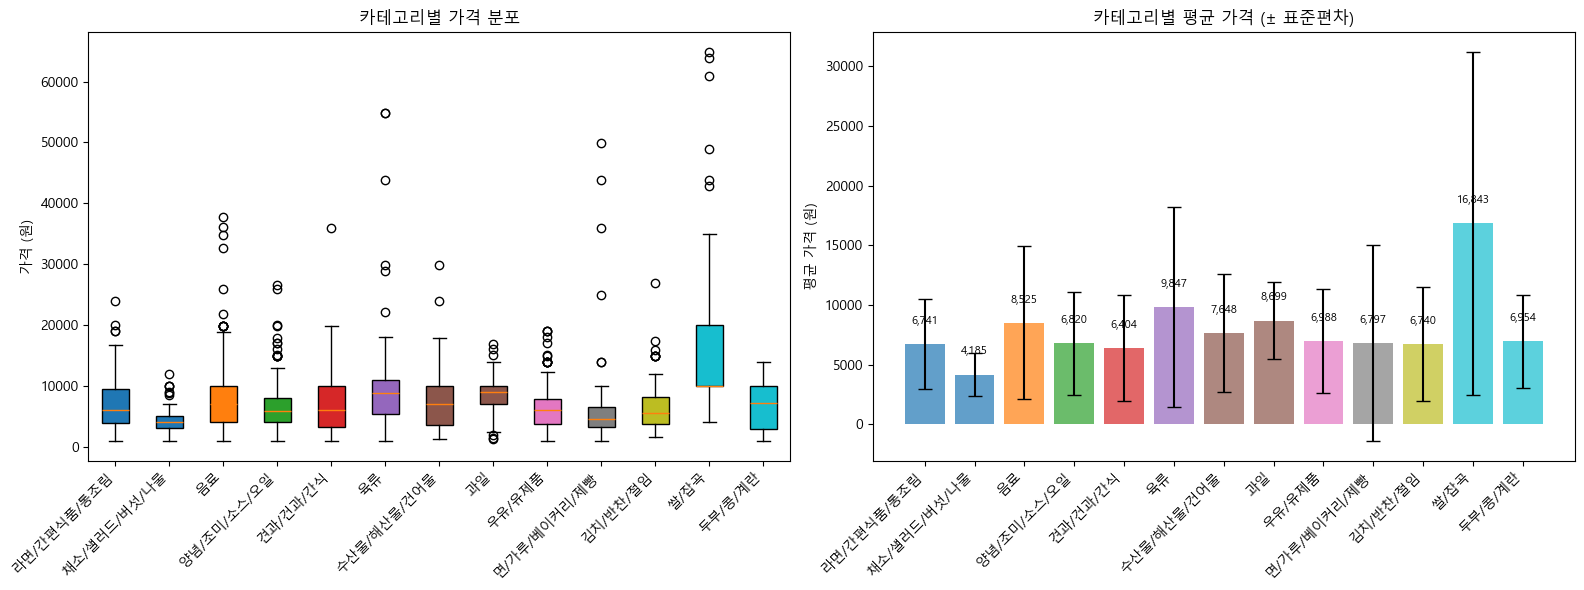

In [7]:
# 카테고리별 가격 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 카테고리별 박스플롯
ax1 = axes[0]
categories_sorted = category_stats.index.tolist()
data_for_boxplot = [df_valid[df_valid['category_name'] == cat]['price'].values for cat in categories_sorted]

bp = ax1.boxplot(data_for_boxplot, vert=True, patch_artist=True, labels=categories_sorted)
colors = plt.cm.tab10(np.linspace(0, 1, len(categories_sorted)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax1.set_xticklabels(categories_sorted, rotation=45, ha='right')
ax1.set_ylabel('가격 (원)')
ax1.set_title('카테고리별 가격 분포')

# 2. 카테고리별 평균 가격
ax2 = axes[1]
means = [category_stats.loc[cat, 'mean'] for cat in categories_sorted]
stds = [category_stats.loc[cat, 'std'] for cat in categories_sorted]

bars = ax2.bar(categories_sorted, means, yerr=stds, capsize=5, color=colors, alpha=0.7)
ax2.set_xticklabels(categories_sorted, rotation=45, ha='right')
ax2.set_ylabel('평균 가격 (원)')
ax2.set_title('카테고리별 평균 가격 (± 표준편차)')

# 값 표시
for bar, mean in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, mean + max(stds)*0.1, 
             f'{mean:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
# 카테고리별 IQR 기반 이상치 경계 계산
category_bounds = {}

print("=" * 70)
print("카테고리별 이상치 경계 (IQR 방식)")
print("=" * 70)

for cat_name in categories_sorted:
    cat_prices = df_valid[df_valid['category_name'] == cat_name]['price']
    
    q1 = cat_prices.quantile(0.25)
    q3 = cat_prices.quantile(0.75)
    iqr = q3 - q1
    
    lower = max(0, q1 - 1.5 * iqr)  # 가격은 0 이상
    upper = q3 + 1.5 * iqr
    
    # 이상치 개수
    n_outliers = ((cat_prices < lower) | (cat_prices > upper)).sum()
    outlier_rate = n_outliers / len(cat_prices) * 100
    
    category_bounds[cat_name] = {
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'n_products': len(cat_prices),
        'n_outliers': n_outliers,
        'outlier_rate': outlier_rate
    }
    
    print(f"\n{cat_name}:")
    print(f"  Q1: {q1:,.0f}, Q3: {q3:,.0f}, IQR: {iqr:,.0f}")
    print(f"  정상 범위: {lower:,.0f} ~ {upper:,.0f}")
    print(f"  이상치: {n_outliers}개 ({outlier_rate:.1f}%)")

카테고리별 이상치 경계 (IQR 방식)

라면/간편식품/통조림:
  Q1: 3,958, Q3: 9,490, IQR: 5,532
  정상 범위: 0 ~ 17,789
  이상치: 4개 (1.6%)

채소/샐러드/버섯/나물:
  Q1: 2,990, Q3: 4,990, IQR: 2,000
  정상 범위: 0 ~ 7,990
  이상치: 7개 (3.7%)

음료:
  Q1: 3,990, Q3: 9,990, IQR: 6,000
  정상 범위: 0 ~ 18,990
  이상치: 12개 (6.6%)

양념/조미/소스/오일:
  Q1: 3,990, Q3: 7,990, IQR: 4,000
  정상 범위: 0 ~ 13,990
  이상치: 14개 (8.1%)

견과/건과/간식:
  Q1: 3,190, Q3: 9,990, IQR: 6,800
  정상 범위: 0 ~ 20,190
  이상치: 1개 (0.6%)

육류:
  Q1: 5,405, Q3: 10,990, IQR: 5,585
  정상 범위: 0 ~ 19,368
  이상치: 6개 (5.1%)

수산물/해산물/건어물:
  Q1: 3,495, Q3: 9,990, IQR: 6,495
  정상 범위: 0 ~ 19,732
  이상치: 2개 (2.1%)

과일:
  Q1: 6,990, Q3: 9,990, IQR: 3,000
  정상 범위: 2,490 ~ 14,490
  이상치: 6개 (6.4%)

우유/유제품:
  Q1: 3,790, Q3: 7,815, IQR: 4,025
  정상 범위: 0 ~ 13,852
  이상치: 13개 (14.1%)

면/가루/베이커리/제빵:
  Q1: 3,260, Q3: 6,465, IQR: 3,205
  정상 범위: 0 ~ 11,272
  이상치: 6개 (7.7%)

김치/반찬/절임:
  Q1: 3,690, Q3: 8,115, IQR: 4,425
  정상 범위: 0 ~ 14,752
  이상치: 8개 (13.3%)

쌀/잡곡:
  Q1: 9,990, Q3: 19,990, IQR: 10,000
  정상 범위: 0 ~ 34

## 4. Z-Score 기반 이상치 분석

In [9]:
# 전체 가격에 대한 Z-Score 계산
df_valid['z_score'] = stats.zscore(df_valid['price'])
df_valid['log_price'] = np.log10(df_valid['price'])
df_valid['z_score_log'] = stats.zscore(df_valid['log_price'])

print("Z-Score 기반 이상치 분석:")
for threshold in [2, 2.5, 3]:
    n_outliers = (np.abs(df_valid['z_score']) > threshold).sum()
    n_outliers_log = (np.abs(df_valid['z_score_log']) > threshold).sum()
    print(f"\n|Z| > {threshold}:")
    print(f"  원본 가격: {n_outliers}개 ({n_outliers/len(df_valid)*100:.2f}%)")
    print(f"  로그 가격: {n_outliers_log}개 ({n_outliers_log/len(df_valid)*100:.2f}%)")

Z-Score 기반 이상치 분석:

|Z| > 2:
  원본 가격: 49개 (3.06%)
  로그 가격: 83개 (5.19%)

|Z| > 2.5:
  원본 가격: 32개 (2.00%)
  로그 가격: 47개 (2.94%)

|Z| > 3:
  원본 가격: 28개 (1.75%)
  로그 가격: 7개 (0.44%)


In [10]:
# 카테고리별 Z-Score 계산
def calculate_category_zscore(group):
    """카테고리 내에서 Z-Score 계산"""
    if len(group) < 3:  # 최소 3개 이상 필요
        return pd.Series([np.nan] * len(group), index=group.index)
    return stats.zscore(group)

df_valid['z_score_within_category'] = df_valid.groupby('category_name')['price'].transform(calculate_category_zscore)

# 로그 가격에 대한 카테고리별 Z-Score
df_valid['z_score_log_within_category'] = df_valid.groupby('category_name')['log_price'].transform(calculate_category_zscore)

print("카테고리별 Z-Score 기반 이상치 분석:")
for threshold in [2, 2.5, 3]:
    n_outliers = (np.abs(df_valid['z_score_within_category']) > threshold).sum()
    n_outliers_log = (np.abs(df_valid['z_score_log_within_category']) > threshold).sum()
    print(f"\n|Z| > {threshold} (카테고리 내):")
    print(f"  원본 가격: {n_outliers}개 ({n_outliers/len(df_valid)*100:.2f}%)")
    print(f"  로그 가격: {n_outliers_log}개 ({n_outliers_log/len(df_valid)*100:.2f}%)")

카테고리별 Z-Score 기반 이상치 분석:

|Z| > 2 (카테고리 내):
  원본 가격: 65개 (4.06%)
  로그 가격: 91개 (5.69%)

|Z| > 2.5 (카테고리 내):
  원본 가격: 42개 (2.62%)
  로그 가격: 33개 (2.06%)

|Z| > 3 (카테고리 내):
  원본 가격: 30개 (1.88%)
  로그 가격: 6개 (0.38%)


## 5. 할인율 분석

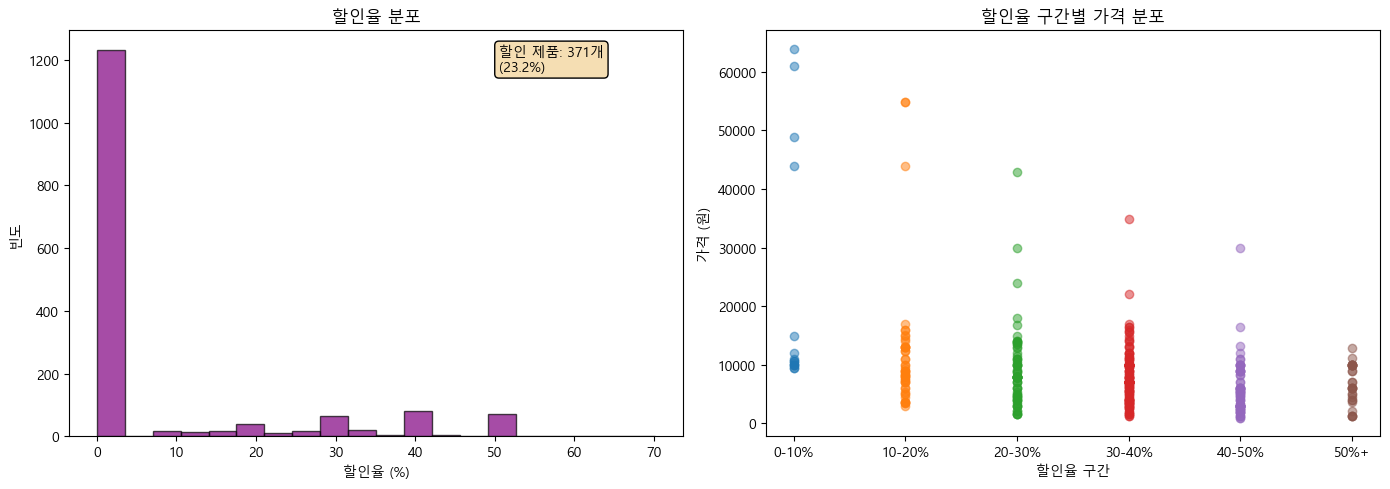


할인율 통계:
count    1600.000000
mean        7.651700
std        15.289999
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        70.170000
Name: discount_rate, dtype: float64


In [11]:
# 할인율 분포
if 'discount_rate' in df_valid.columns and df_valid['discount_rate'].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. 할인율 분포
    ax1 = axes[0]
    discount_rates = df_valid['discount_rate'].fillna(0)
    ax1.hist(discount_rates, bins=20, edgecolor='black', alpha=0.7, color='purple')
    ax1.set_xlabel('할인율 (%)')
    ax1.set_ylabel('빈도')
    ax1.set_title('할인율 분포')
    
    # 할인 제품 비율
    discounted = (discount_rates > 0).sum()
    ax1.text(0.7, 0.9, f'할인 제품: {discounted}개\n({discounted/len(df_valid)*100:.1f}%)', 
             transform=ax1.transAxes, fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))
    
    # 2. 할인율별 가격 분포
    ax2 = axes[1]
    discount_bins = pd.cut(discount_rates, bins=[0, 10, 20, 30, 40, 50, 100], labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+'])
    df_valid['discount_bin'] = discount_bins
    
    for i, dbin in enumerate(discount_bins.cat.categories):
        subset = df_valid[df_valid['discount_bin'] == dbin]['price']
        if len(subset) > 0:
            ax2.scatter([i] * len(subset), subset, alpha=0.5, label=dbin)
    
    ax2.set_xticks(range(len(discount_bins.cat.categories)))
    ax2.set_xticklabels(discount_bins.cat.categories)
    ax2.set_xlabel('할인율 구간')
    ax2.set_ylabel('가격 (원)')
    ax2.set_title('할인율 구간별 가격 분포')
    
    plt.tight_layout()
    plt.show()
    
    # 할인율 통계
    print("\n할인율 통계:")
    print(discount_rates.describe())
else:
    print("할인율 데이터가 없습니다.")

## 6. 이상치 탐지 방법 비교

In [12]:
# 다양한 이상치 탐지 방법 비교
ZSCORE_THRESHOLD = 2.5

# 방법 1: 전체 IQR
outliers_iqr_global = (df_valid['price'] < lower_bound) | (df_valid['price'] > upper_bound)

# 방법 2: 카테고리별 IQR
outliers_iqr_category = pd.Series(False, index=df_valid.index)
for cat_name, bounds in category_bounds.items():
    cat_mask = df_valid['category_name'] == cat_name
    cat_prices = df_valid.loc[cat_mask, 'price']
    outliers_iqr_category.loc[cat_mask] = (cat_prices < bounds['lower_bound']) | (cat_prices > bounds['upper_bound'])

# 방법 3: 전체 Z-Score
outliers_zscore_global = np.abs(df_valid['z_score']) > ZSCORE_THRESHOLD

# 방법 4: 카테고리별 Z-Score
outliers_zscore_category = np.abs(df_valid['z_score_within_category']) > ZSCORE_THRESHOLD

# 방법 5: 로그 변환 + 카테고리별 Z-Score (권장)
outliers_log_zscore_category = np.abs(df_valid['z_score_log_within_category']) > ZSCORE_THRESHOLD

# 결과 비교
print("=" * 60)
print("이상치 탐지 방법 비교")
print("=" * 60)

methods = [
    ('전체 IQR', outliers_iqr_global),
    ('카테고리별 IQR', outliers_iqr_category),
    ('전체 Z-Score', outliers_zscore_global),
    ('카테고리별 Z-Score', outliers_zscore_category),
    ('로그+카테고리별 Z-Score', outliers_log_zscore_category)
]

for name, outliers in methods:
    n_outliers = outliers.sum()
    print(f"\n{name}:")
    print(f"  이상치 수: {n_outliers}개 ({n_outliers/len(df_valid)*100:.2f}%)")

이상치 탐지 방법 비교

전체 IQR:
  이상치 수: 49개 (3.06%)

카테고리별 IQR:
  이상치 수: 85개 (5.31%)

전체 Z-Score:
  이상치 수: 32개 (2.00%)

카테고리별 Z-Score:
  이상치 수: 42개 (2.62%)

로그+카테고리별 Z-Score:
  이상치 수: 33개 (2.06%)


In [13]:
# 방법별 이상치 오버랩 분석
df_valid['outlier_iqr_global'] = outliers_iqr_global
df_valid['outlier_iqr_category'] = outliers_iqr_category
df_valid['outlier_zscore_global'] = outliers_zscore_global
df_valid['outlier_zscore_category'] = outliers_zscore_category.fillna(False)
df_valid['outlier_log_zscore_category'] = outliers_log_zscore_category.fillna(False)

# 모든 방법에서 이상치로 탐지된 경우
all_methods_outlier = (
    df_valid['outlier_iqr_global'] & 
    df_valid['outlier_iqr_category'] & 
    df_valid['outlier_zscore_global'] & 
    df_valid['outlier_zscore_category'] &
    df_valid['outlier_log_zscore_category']
)

# 최소 3개 방법에서 이상치로 탐지된 경우
outlier_count = (
    df_valid['outlier_iqr_global'].astype(int) + 
    df_valid['outlier_iqr_category'].astype(int) + 
    df_valid['outlier_zscore_global'].astype(int) + 
    df_valid['outlier_zscore_category'].astype(int) +
    df_valid['outlier_log_zscore_category'].astype(int)
)

majority_outlier = outlier_count >= 3

print("이상치 오버랩 분석:")
print(f"  모든 방법(5/5): {all_methods_outlier.sum()}개")
print(f"  다수결(>=3/5): {majority_outlier.sum()}개")
print(f"  적어도 1개: {(outlier_count >= 1).sum()}개")

이상치 오버랩 분석:
  모든 방법(5/5): 11개
  다수결(>=3/5): 30개
  적어도 1개: 118개


## 7. 최종 분석 결과 저장

In [14]:
# 분석 결과 저장
import pickle
from datetime import datetime

OUTPUT_DIR = Path('../data/processed/price')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

price_analysis_results = {
    'version': '1.0.0',
    'created_at': datetime.now(),
    'use_real_data': USE_REAL_DATA,
    
    'global_stats': price_stats,
    'category_stats': category_stats.to_dict(),
    'category_bounds': category_bounds,
    
    'recommended_method': 'log_zscore_within_category',
    'recommended_threshold': ZSCORE_THRESHOLD,
    
    'n_products': len(df_valid),
    'n_categories': len(category_bounds)
}

output_path = OUTPUT_DIR / 'price_analysis_results.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(price_analysis_results, f)

print(f"분석 결과 저장 완료: {output_path}")

분석 결과 저장 완료: ..\data\processed\price\price_analysis_results.pkl


In [15]:
# 가격 데이터프레임 저장 (다음 노트북에서 사용)
df_export = df_valid[['product_id', 'name', 'price', 'original_price', 'discount_rate', 
                       'category_id', 'category_name', 'log_price']].copy()

df_export_path = OUTPUT_DIR / 'price_data.pkl'
df_export.to_pickle(df_export_path)

print(f"가격 데이터 저장 완료: {df_export_path}")
print(f"저장된 제품 수: {len(df_export)}")

가격 데이터 저장 완료: ..\data\processed\price\price_data.pkl
저장된 제품 수: 1600


## 8. 요약 및 권장사항

### 분석 결과 요약

In [16]:
print("=" * 60)
print("가격 데이터 탐색 결과 요약")
print("=" * 60)

print(f"\n📊 데이터 규모:")
print(f"   총 제품 수: {len(df_valid):,}개")
print(f"   카테고리 수: {len(category_bounds)}개")
print(f"   데이터 소스: {'실제 DB' if USE_REAL_DATA else '시뮬레이션'}")

print(f"\n💰 가격 분포:")
print(f"   평균: {price_stats['mean']:,.0f}원")
print(f"   중앙값: {price_stats['median']:,.0f}원")
print(f"   표준편차: {price_stats['std']:,.0f}원")
print(f"   범위: {price_stats['min']:,.0f} ~ {price_stats['max']:,.0f}원")

print(f"\n⚠️ 이상치 현황:")
print(f"   IQR 방식 (전체): {outliers_iqr_global.sum()}개 ({outliers_iqr_global.sum()/len(df_valid)*100:.2f}%)")
print(f"   IQR 방식 (카테고리별): {outliers_iqr_category.sum()}개 ({outliers_iqr_category.sum()/len(df_valid)*100:.2f}%)")
print(f"   Z-Score 방식 (카테고리별): {outliers_zscore_category.sum()}개 ({outliers_zscore_category.sum()/len(df_valid)*100:.2f}%)")

print(f"\n✅ 권장 이상치 탐지 방법:")
print(f"   로그 변환 + 카테고리별 Z-Score (threshold={ZSCORE_THRESHOLD})")
print(f"   이유: 가격 분포의 비대칭성 보정 + 카테고리별 특성 반영")

print("\n" + "=" * 60)

가격 데이터 탐색 결과 요약

📊 데이터 규모:
   총 제품 수: 1,600개
   카테고리 수: 13개
   데이터 소스: 실제 DB

💰 가격 분포:
   평균: 7,421원
   중앙값: 5,990원
   표준편차: 6,095원
   범위: 890 ~ 64,900원

⚠️ 이상치 현황:
   IQR 방식 (전체): 49개 (3.06%)
   IQR 방식 (카테고리별): 85개 (5.31%)
   Z-Score 방식 (카테고리별): 42개 (2.62%)

✅ 권장 이상치 탐지 방법:
   로그 변환 + 카테고리별 Z-Score (threshold=2.5)
   이유: 가격 분포의 비대칭성 보정 + 카테고리별 특성 반영



## 검증 체크리스트

### 필수 확인 항목
- [ ] 가격 데이터 로드 성공
- [ ] 전체 가격 분포 시각화 확인
- [ ] 카테고리별 통계 확인
- [ ] 다양한 이상치 탐지 방법 비교
- [ ] 분석 결과 파일 저장 완료

### 다음 단계
31번 노트북에서 Price Anomaly Detection 모델을 구현합니다:
- Modified Z-Score 방식 구현
- 카테고리별 통계 기반 이상치 탐지
- 이상치 심각도 스코어링